# Generate Report — Own Data (fix_classified_prs, AIDev-Filtered)

Replicates all three RQs from `generate_report.ipynb` using own-classifier data.

**Agent PRs** are filtered to the AIDev-overlapping subset (apple-to-apple, ~2,620 PRs)
by matching `repo_name#number` keys against the local AIDev parquet files.
This reproduces the **~52% acceptance rate** from `own_data_acceptance_rate_fixes.ipynb`.

**Human PRs** are restricted to the **same repositories** as the filtered agent PRs,
ensuring a fair apple-to-apple comparison (controlling for repo-level effects).

**Produces:**

- `results/own_data_report_figures/` — PNG figures
- `results/own_data_report.txt` — text summary with tables


In [1]:
%pip install matplotlib seaborn scipy pyarrow fsspec requests lifelines

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports & Setup

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

## Paths

In [3]:
OUT_DIR = Path("results")
FIG_DIR = OUT_DIR / "own_data_report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "own_data_report.txt"

## Load Data

Primary source: `fix_classified_prs.parquet` (own classifier, both agent + human).

- **Agent PRs**: filtered to AIDev-matching keys (requires local `pull_request.parquet` + `pr_task_type.parquet`).
- **Human PRs**: restricted to the same repositories as the filtered agent PRs, then **randomly sampled to match the agent PR count** (balanced, apple-to-apple comparison).

We join with `fix_prs_only.parquet` to obtain the `id` / `body` / `closed_at` columns
needed for commit lookups and RQ calculations.


In [4]:
HF_BASE = "https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset/resolve/main"

print("Loading fix_classified_prs from HuggingFace ...")
classified_raw = pd.read_parquet(f"{HF_BASE}/fix_classified_prs.parquet")
print(f"  Loaded {len(classified_raw):,} rows | columns: {list(classified_raw.columns)}")

# ── Base filter: fix-type, closed, no Codex ──
classified_df = classified_raw[
    (classified_raw["type"] == "fix") &
    (classified_raw["state"] == "closed") &
    (classified_raw["agent"] != "OpenAI_Codex")
].copy()
classified_df["created_at"] = pd.to_datetime(classified_df["created_at"], errors="coerce")
classified_df["match_key"] = classified_df["repo_name"] + "#" + classified_df["number"].astype(str)

print(f"  After base filtering (fix, closed, no Codex): {len(classified_df):,}")
print(f"  Source breakdown:\n{classified_df['source'].value_counts()}")

# ── Build AIDev match keys from local parquet files ──
print("\nBuilding AIDev match keys from local parquet files ...")
aidev_pr = pd.read_parquet("pull_request.parquet",
                           columns=["id", "repo_url", "number", "state", "agent", "merged_at", "created_at"])
aidev_task = pd.read_parquet("pr_task_type.parquet", columns=["id", "type"])

aidev_pr["repo_name"] = aidev_pr["repo_url"].str.replace(
    "https://api.github.com/repos/", "", regex=False
)
aidev_fix_ids = set(aidev_task[aidev_task["type"] == "fix"]["id"])
aidev_agents = aidev_pr[
    aidev_pr["id"].isin(aidev_fix_ids) &
    (aidev_pr["state"] == "closed") &
    (aidev_pr["agent"] != "OpenAI_Codex")
].copy()
aidev_keys = set(aidev_agents["repo_name"] + "#" + aidev_agents["number"].astype(str))
print(f"  AIDev fix PRs (closed, no Codex): {len(aidev_keys):,} unique match keys")

Loading fix_classified_prs from HuggingFace ...
  Loaded 1,959,649 rows | columns: ['id', 'number', 'title', 'body', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'repo_name', 'html_url', 'is_agent', 'agent', 'type', 'source']
  After base filtering (fix, closed, no Codex): 404,700
  Source breakdown:
source
human    288689
agent    116011
Name: count, dtype: int64

Building AIDev match keys from local parquet files ...
  AIDev fix PRs (closed, no Codex): 3,225 unique match keys


In [51]:
# ── Diagnostic: check date coverage in the loaded data ──
print("=== Date coverage in fix_classified_prs (HuggingFace) ===\n")

classified_raw["created_at_dt"] = pd.to_datetime(classified_raw["created_at"], errors="coerce")
print(f"Overall range: {classified_raw['created_at_dt'].min()} → {classified_raw['created_at_dt'].max()}")

monthly_counts = (
    classified_raw["created_at_dt"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)
print(f"\nMonthly row counts (all rows, both sources):")
print(monthly_counts.to_string())

print("\nMonthly counts by source:")
for src, grp in classified_raw.groupby("source"):
    mc = grp["created_at_dt"].dt.to_period("M").value_counts().sort_index()
    print(f"\n  source={src}")
    print(mc.to_string())


=== Date coverage in fix_classified_prs (HuggingFace) ===

Overall range: 2024-12-01 00:03:14+00:00 → 2026-02-28 23:58:23+00:00

Monthly row counts (all rows, both sources):
created_at_dt
2024-12     85013
2025-01     97746
2025-02    103899
2025-03    117487
2025-04    116955
2025-05    126436
2025-06    159086
2025-07    229281
2025-08    143626
2025-09    131815
2025-10    134037
2025-11    119143
2025-12    118630
2026-01    133669
2026-02    142826
Freq: M

Monthly counts by source:


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\1340849098.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")



  source=agent
created_at_dt
2024-12     23661
2025-01     27984
2025-02     29760
2025-03     35519
2025-04     36091
2025-05     48321
2025-06     80638
2025-07    137590
2025-08     66043
2025-09     51840
2025-10     50371
2025-11     44887
2025-12     44722
2026-01     46849
2026-02     49237
Freq: M

  source=human
created_at_dt
2024-12    61352
2025-01    69762
2025-02    74139
2025-03    81968
2025-04    80864
2025-05    78115
2025-06    78448
2025-07    91691
2025-08    77583
2025-09    79975
2025-10    83666
2025-11    74256
2025-12    73908
2026-01    86820
2026-02    93589
Freq: M


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\1340849098.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mc = grp["created_at_dt"].dt.to_period("M").value_counts().sort_index()


In [56]:
# ── Agent PRs: AIDev-filtered for months covered by AIDev; own-classifier for the rest ──
agent_aidev = classified_df[
    (classified_df["source"] == "agent") &
    (classified_df["match_key"].isin(aidev_keys))
].copy()

# Months covered by the AIDev dataset
aidev_months = set(agent_aidev["created_at"].dt.to_period("M").unique())

# For months NOT in AIDev (Aug 2025 – Feb 2026), use own-classifier agent PRs directly
agent_other = classified_df[
    (classified_df["source"] == "agent") &
    (~classified_df["created_at"].dt.to_period("M").isin(aidev_months))
].copy()

agent_classified = pd.concat([agent_aidev, agent_other], ignore_index=True)

print(f"Agent PRs — AIDev-filtered months   : {len(agent_aidev):,}  ({sorted(str(m) for m in aidev_months)[0]} – {sorted(str(m) for m in aidev_months)[-1]})")
print(f"Agent PRs — own-classifier months   : {len(agent_other):,}  (months not in AIDev)")
print(f"Agent PRs — total                   : {len(agent_classified):,}")

# ── Human PRs: restricted to same repos, then per-month sampled to match agent counts ──
agent_repos = set(agent_classified["repo_name"])
human_pool = classified_df[
    (classified_df["source"] == "human") &
    (classified_df["repo_name"].isin(agent_repos))
].copy()

agent_classified["_month"] = agent_classified["created_at"].dt.to_period("M")
human_pool["_month"] = human_pool["created_at"].dt.to_period("M")

RANDOM_SEED = 42
human_samples = []
print(f"\nPer-month sampling (human PRs to match agent count):")
print(f"{'Month':<12} {'Agent':>8} {'H-pool':>10} {'H-sampled':>10}")
print("-" * 44)
for month, agent_grp in agent_classified.groupby("_month"):
    n = len(agent_grp)
    h_pool_m = human_pool[human_pool["_month"] == month]
    if len(h_pool_m) >= n:
        sampled = h_pool_m.sample(n=n, random_state=RANDOM_SEED)
    else:
        sampled = h_pool_m.copy()
    human_samples.append(sampled)
    print(f"{str(month):<12} {n:>8,} {len(h_pool_m):>10,} {len(sampled):>10,}")

human_classified = pd.concat(human_samples, ignore_index=True).drop(columns=["_month"])
agent_classified = agent_classified.drop(columns=["_month"])

print(f"\nTotal human PRs sampled : {len(human_classified):,}")
print(f"Repos in common         : {len(agent_repos):,}")

# ── Join with fix_prs_only.parquet to get id / body / closed_at ──
# Use LEFT join so PRs from months not in the HF snapshot are not dropped
print("\nJoining with fix_prs_only.parquet for id/body/closed_at ...")
prs_only = pd.read_parquet(f"{HF_BASE}/fix_prs_only.parquet")
prs_only = prs_only[prs_only["state"] == "closed"].copy()
prs_only["match_key"] = prs_only["repo_name"] + "#" + prs_only["number"].astype(str)

extra_cols = [c for c in ["id", "body", "closed_at"] if c not in classified_df.columns]
prs_lookup = prs_only[["match_key"] + extra_cols].drop_duplicates("match_key")

agent_classified = agent_classified.merge(prs_lookup, on="match_key", how="left")
human_classified = human_classified.merge(prs_lookup, on="match_key", how="left")

print(f"Agent PRs after join : {len(agent_classified):,}  (missing id: {agent_classified['id'].isna().sum():,})")
print(f"Human PRs after join : {len(human_classified):,}  (missing id: {human_classified['id'].isna().sum():,})")

all_prs = pd.concat([agent_classified, human_classified], ignore_index=True)

for col in ["body", "closed_at"]:
    if col not in all_prs.columns:
        all_prs[col] = None

print(f"\nFinal all_prs: {len(all_prs):,} rows")
print(f"Columns: {list(all_prs.columns)}")


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3732309451.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  aidev_months = set(agent_aidev["created_at"].dt.to_period("M").unique())
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3732309451.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  (~classified_df["created_at"].dt.to_period("M").isin(aidev_months))


Agent PRs — AIDev-filtered months   : 2,620  (2024-12 – 2025-07)
Agent PRs — own-classifier months   : 50,652  (months not in AIDev)
Agent PRs — total                   : 53,272


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3732309451.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  agent_classified["_month"] = agent_classified["created_at"].dt.to_period("M")
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3732309451.py:30: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  human_pool["_month"] = human_pool["created_at"].dt.to_period("M")



Per-month sampling (human PRs to match agent count):
Month           Agent     H-pool  H-sampled
--------------------------------------------
2024-12            17     12,890         17
2025-01            90     14,693         90
2025-02           134     15,672        134
2025-03           193     17,435        193
2025-04           186     17,370        186
2025-05           421     16,773        421
2025-06           717     17,348        717
2025-07           862     19,692        862
2025-08        10,802     17,018     10,802
2025-09         7,123     18,299      7,123
2025-10         6,396     19,078      6,396
2025-11         6,154     17,613      6,154
2025-12         5,816     17,847      5,816
2026-01         6,851     20,418      6,851
2026-02         7,510     22,144      7,510

Total human PRs sampled : 53,272
Repos in common         : 3,625

Joining with fix_prs_only.parquet for id/body/closed_at ...


ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host

In [31]:
# Split by source
agent_prs = all_prs[all_prs["source"] == "agent"].copy()
human_prs = all_prs[all_prs["source"] == "human"].copy()

print(f"Agent fix PRs : {len(agent_prs):,}")
print(f"Human fix PRs : {len(human_prs):,}")

# Load commits and commit details
print("\nLoading commits and commit details ...")
commits_full = pd.read_parquet(f"{HF_BASE}/fix_pr_commits.parquet")
details_full = pd.read_parquet(
    f"{HF_BASE}/fix_pr_commit_details.parquet",
    columns=["sha", "pr_id", "filename", "additions", "deletions"],
)

# Restrict commits/details to our PR set
pr_ids = set(all_prs["id"])
commits = commits_full[commits_full["pr_id"].isin(pr_ids)].copy()
details = details_full[details_full["pr_id"].isin(pr_ids)].copy()

print(f"Commits  : {len(commits):,}")
print(f"Details  : {len(details):,}")

Agent fix PRs : 2,620
Human fix PRs : 2,620

Loading commits and commit details ...
Commits  : 15,497
Details  : 82,951


## Helper Functions

In [32]:
def word_count(text) -> int:
    if not text or not isinstance(text, str):
        return 0
    return len(text.split())


report_lines: list[str] = []

def section(title: str):
    report_lines.append("")
    report_lines.append("=" * 70)
    report_lines.append(f"  {title}")
    report_lines.append("=" * 70)
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")

def out(line: str = ""):
    report_lines.append(line)
    print(line)

## Dataset Overview

In [33]:
section("Dataset Overview (Own Data — Closed Fix PRs, Agent + Human)")
out(f"Data source        : fix_classified_prs.parquet (type='fix')")
created_min = all_prs["created_at"].min()
created_max = all_prs["created_at"].max()
out(f"Date range         : {str(created_min)[:10]} to {str(created_max)[:10]}")
out(f"Total closed fix PRs : {len(all_prs):,}")
out(f"  Agent fix PRs      : {len(agent_prs):,}")
out(f"  Human fix PRs      : {len(human_prs):,}")
out(f"Repositories       : {all_prs['repo_name'].nunique():,}")
out(f"Total commits      : {len(commits):,}")
out(f"Unique committers  : {commits['author'].nunique() if 'author' in commits.columns else 'N/A'}")

if "agent" in agent_prs.columns:
    out("\nAgent fix PR breakdown:")
    for ag, cnt in agent_prs["agent"].value_counts().items():
        out(f"  {ag:20s} {cnt:>8,}")


  Dataset Overview (Own Data — Closed Fix PRs, Agent + Human)
Data source        : fix_classified_prs.parquet (type='fix')
Date range         : 2024-12-01 to 2026-02-28
Total closed fix PRs : 5,240
  Agent fix PRs      : 2,620
  Human fix PRs      : 2,620
Repositories       : 682
Total commits      : 15,497
Unique committers  : 1674

Agent fix PR breakdown:
  Copilot                 1,175
  Devin                   1,080
  Cursor                    290
  Claude_Code                75


## RQ1 — Fix PR Change Size

**How do Agent fix PRs differ from Human fix PRs in change size?**

In [34]:
section("RQ1: How do Agent fix PRs differ from Human fix PRs in change size?")

pr_stats = details.groupby("pr_id").agg(
    files_changed=("filename", "nunique"),
    lines_added=("additions", "sum"),
    lines_deleted=("deletions", "sum"),
).reset_index()

agent_ids = set(agent_prs["id"])
human_ids = set(human_prs["id"])

apr_stats = pr_stats[pr_stats["pr_id"].isin(agent_ids)]
hpr_stats = pr_stats[pr_stats["pr_id"].isin(human_ids)]

out("\nChange size (median):")
for metric in ["files_changed", "lines_added", "lines_deleted"]:
    a_med = apr_stats[metric].median() if len(apr_stats) else 0
    h_med = hpr_stats[metric].median() if len(hpr_stats) else 0
    out(f"  {metric:<20s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

agent_prs["desc_words"] = agent_prs["body"].apply(word_count)
human_prs["desc_words"] = human_prs["body"].apply(word_count)
out(f"\nPR description length (median words):  APR: {agent_prs['desc_words'].median():.0f}   HPR: {human_prs['desc_words'].median():.0f}")


  RQ1: How do Agent fix PRs differ from Human fix PRs in change size?

Change size (median):
  files_changed         APR:        2   HPR:        2
  lines_added           APR:       57   HPR:       22
  lines_deleted         APR:       12   HPR:        7

PR description length (median words):  APR: 214   HPR: 77


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3293022772.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3293022772.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3293022772.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


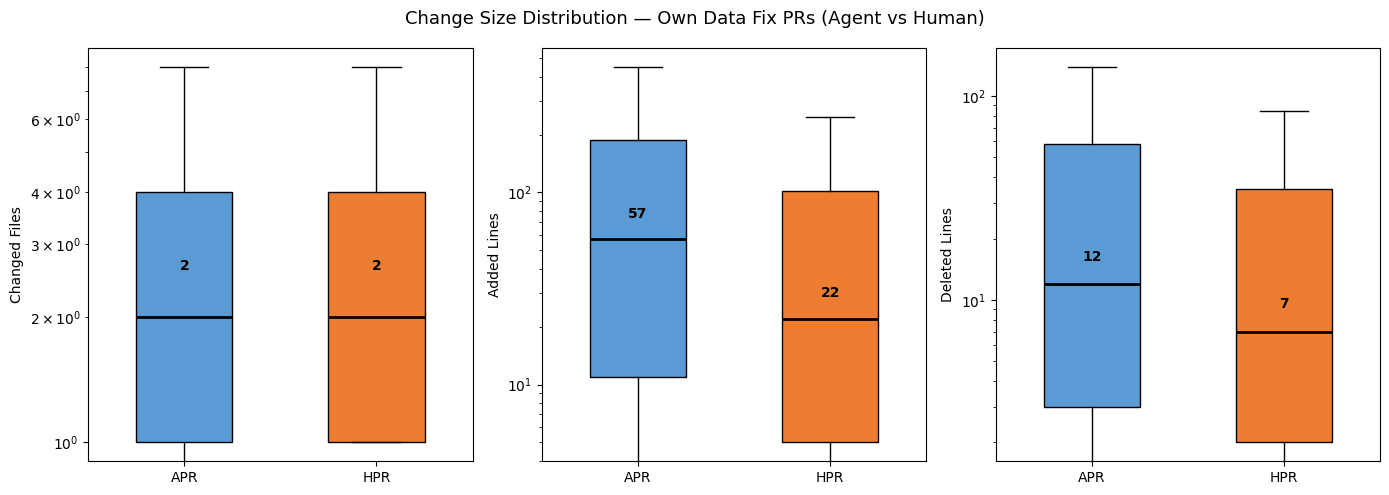

  -> Figure saved: results\own_data_report_figures\rq1_change_size.png


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3293022772.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,


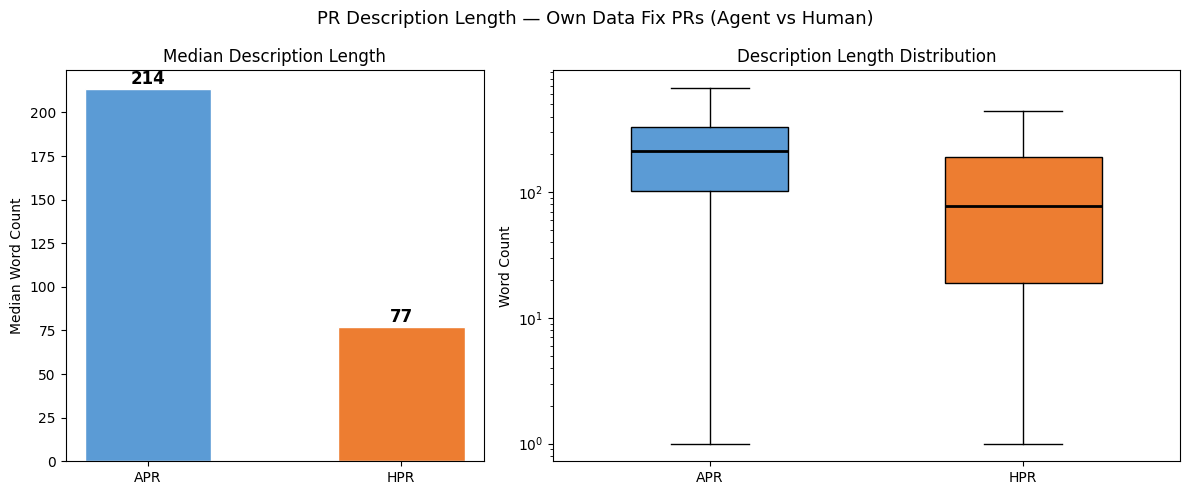

  -> Figure saved: results\own_data_report_figures\rq1_description_length.png


In [35]:
# ── Figure 1: Code Change Size — Box plots on log scale ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["files_changed", "lines_added", "lines_deleted"]
titles_m = ["Changed Files", "Added Lines", "Deleted Lines"]

for ax, metric, title in zip(axes, metrics, titles_m):
    data = [
        apr_stats[metric].dropna().values,
        hpr_stats[metric].dropna().values,
    ]
    bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#5b9bd5")
    bp["boxes"][1].set_facecolor("#ed7d31")
    ax.set_yscale("log")
    ax.set_ylabel(title)
    for i, vals in enumerate(data):
        if len(vals):
            med = np.median(vals)
            ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Change Size Distribution — Own Data Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_change_size.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_change_size.png'}")

# ── Figure 2: PR Description Length ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.5]})

apr_med = agent_prs["desc_words"].median()
hpr_med = human_prs["desc_words"].median()
bars = axes[0].bar(["APR", "HPR"], [apr_med, hpr_med],
                   color=["#5b9bd5", "#ed7d31"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [apr_med, hpr_med]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"{val:.0f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Median Word Count")
axes[0].set_title("Median Description Length")

data_desc = [
    agent_prs["desc_words"].clip(lower=1).values,
    human_prs["desc_words"].clip(lower=1).values,
]
bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,
                     widths=0.5, showfliers=False,
                     medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
axes[1].set_yscale("log")
axes[1].set_ylabel("Word Count")
axes[1].set_title("Description Length Distribution")

fig.suptitle("PR Description Length — Own Data Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_description_length.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_description_length.png'}")

## RQ2 — Acceptance / Rejection Rates

**To what extent are Agent fix PRs rejected?**

In [36]:
section("RQ2: To what extent are Agent fix PRs rejected?")

def merge_rate(df: pd.DataFrame) -> tuple[int, int, float]:
    merged = df["merged_at"].notna().sum()
    total = len(df)
    return merged, total, merged / total * 100 if total else 0

apr_m, apr_t, apr_r = merge_rate(agent_prs)
hpr_m, hpr_t, hpr_r = merge_rate(human_prs)

out(f"Agent PRs  : {apr_m:,} / {apr_t:,} merged  = {apr_r:.1f}%")
out(f"Human PRs  : {hpr_m:,} / {hpr_t:,} merged  = {hpr_r:.1f}%")

contingency = np.array([[apr_m, apr_t - apr_m], [hpr_m, hpr_t - hpr_m]])
if contingency.min() > 0:
    chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
    out(f"Chi-squared test: chi2={chi2:.2f}, p={p_chi:.4f}")
    out(f"  {'Statistically significant' if p_chi < 0.05 else 'Not statistically significant'} at alpha=0.05")

if "agent" in agent_prs.columns:
    out("\nMerge rate by agent tool:")
    for agent_name, grp in agent_prs.groupby("agent"):
        m, t, r = merge_rate(grp)
        out(f"  {agent_name:20s}  {m:>6,} / {t:>6,}  = {r:.1f}%")


  RQ2: To what extent are Agent fix PRs rejected?
Agent PRs  : 1,367 / 2,620 merged  = 52.2%
Human PRs  : 2,261 / 2,620 merged  = 86.3%
Chi-squared test: chi2=714.50, p=0.0000
  Statistically significant at alpha=0.05

Merge rate by agent tool:
  Claude_Code               53 /     75  = 70.7%
  Copilot                  655 /  1,175  = 55.7%
  Cursor                   228 /    290  = 78.6%
  Devin                    431 /  1,080  = 39.9%


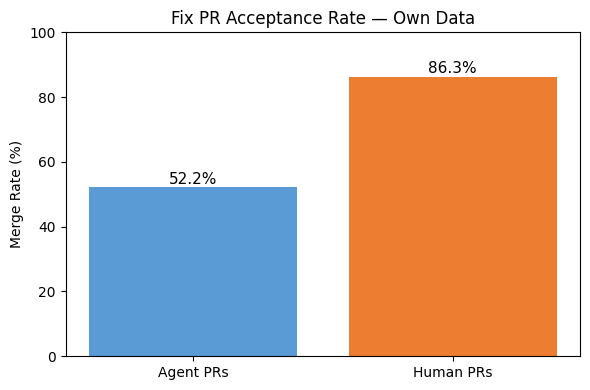


  -> Figure saved: results\own_data_report_figures\rq2_merge_rate.png


In [37]:
# Merge rate bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Agent PRs", "Human PRs"], [apr_r, hpr_r], color=["#5b9bd5", "#ed7d31"])
ax.set_ylabel("Merge Rate (%)")
ax.set_title("Fix PR Acceptance Rate — Own Data")
ax.set_ylim(0, 100)
for bar, val in zip(bars, [apr_r, hpr_r]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%",
            ha="center", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_merge_rate.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_merge_rate.png'}")


Agent PRs — median time to merge: 3.63 hours

Human PRs — median time to merge: 5.12 hours


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\159070273.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,


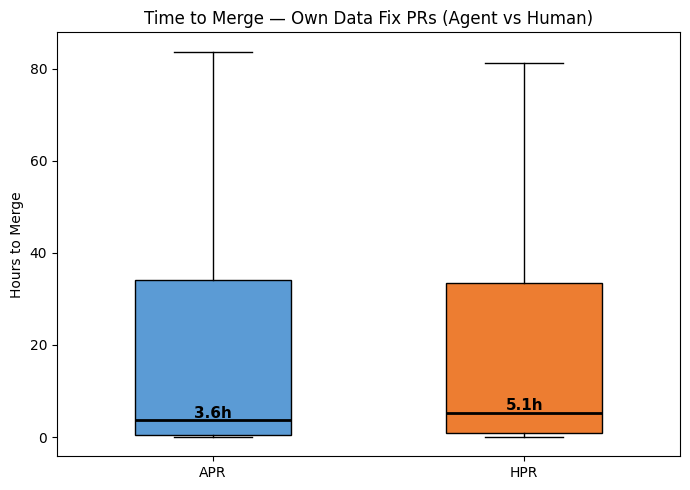

  -> Figure saved: results\own_data_report_figures\rq2_time_to_merge.png


In [38]:
# Time to merge
merge_times = {}
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    merged_df = df[df["merged_at"].notna()].copy()
    if len(merged_df) == 0:
        continue
    merged_df["created_dt"] = pd.to_datetime(merged_df["created_at"], utc=True)
    merged_df["merged_dt"] = pd.to_datetime(merged_df["merged_at"], utc=True)
    merged_df["hours_to_merge"] = (merged_df["merged_dt"] - merged_df["created_dt"]).dt.total_seconds() / 3600
    merge_times[label] = merged_df["hours_to_merge"]
    out(f"\n{label} PRs — median time to merge: {merged_df['hours_to_merge'].median():.2f} hours")

if len(merge_times) == 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    data_ttm = [
        merge_times["Agent"].clip(upper=merge_times["Agent"].quantile(0.95)).values,
        merge_times["Human"].clip(upper=merge_times["Human"].quantile(0.95)).values,
    ]
    bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#5b9bd5")
    bp["boxes"][1].set_facecolor("#ed7d31")
    for i, vals in enumerate(data_ttm):
        med = np.median(vals)
        ax.text(i + 1, med * 1.15, f"{med:.1f}h", ha="center", fontsize=11, fontweight="bold")
    ax.set_ylabel("Hours to Merge")
    ax.set_title("Time to Merge — Own Data Fix PRs (Agent vs Human)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_time_to_merge.png", dpi=150)
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq2_time_to_merge.png'}")

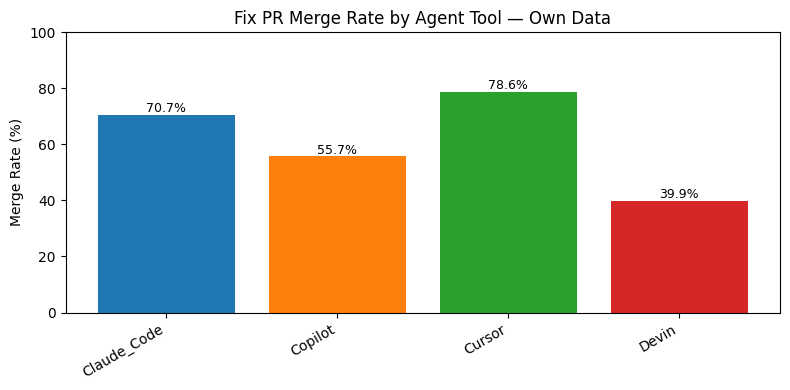

  -> Figure saved: results\own_data_report_figures\rq2_merge_rate_by_agent.png


In [39]:
# Merge rate by agent (grouped bar)
if "agent" in agent_prs.columns:
    agents_list = sorted(agent_prs["agent"].unique())
    merge_rates = [merge_rate(agent_prs[agent_prs["agent"] == a])[2] for a in agents_list]

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = sns.color_palette("tab10", len(agents_list))
    ax.bar(agents_list, merge_rates, color=colors)
    ax.set_ylabel("Merge Rate (%)")
    ax.set_title("Fix PR Merge Rate by Agent Tool — Own Data")
    ax.set_ylim(0, 100)
    for i, r in enumerate(merge_rates):
        ax.text(i, r + 1, f"{r:.1f}%", ha="center", fontsize=9)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_merge_rate_by_agent.png", dpi=150)
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq2_merge_rate_by_agent.png'}")

In [40]:
# ── Table 2 (replication): Acceptance and merge time statistics ──
from lifelines.statistics import logrank_test

def compute_row(label, df):
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged = df[df["merged_at"].notna()].copy()
    if len(merged):
        merged["hours"] = (
            pd.to_datetime(merged["merged_at"], utc=True)
            - pd.to_datetime(merged["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}"]

rows = [
    compute_row("APRs", agent_prs),
    compute_row("HPRs", human_prs),
]
if "agent" in agent_prs.columns:
    for ag in sorted(agent_prs["agent"].unique()):
        rows.append(compute_row(f"  APR – {ag}", agent_prs[agent_prs["agent"] == ag]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
print("Table 2. Acceptance and merge time statistics of PRs (Own Data).\n")
display(summary_df)

# Chi-squared
apr_acc = int(agent_prs["merged_at"].notna().sum())
apr_rej = int(agent_prs["merged_at"].isna().sum())
hpr_acc = int(human_prs["merged_at"].notna().sum())
hpr_rej = int(human_prs["merged_at"].isna().sum())
contingency = np.array([[apr_acc, apr_rej], [hpr_acc, hpr_rej]])
chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
print(f"\nChi-squared test (acceptance): χ²={chi2:.2f}, p={p_chi:.6f}")
print(f"  → {'Statistically significant' if p_chi < 0.05 else 'Not significant'} at α=0.05")

# Log-rank test
def hours_to_merge(df):
    tmp = df.copy()
    tmp["merged"] = tmp["merged_at"].notna().astype(int)
    tmp["hours"] = (
        pd.to_datetime(tmp["closed_at"], utc=True)
        - pd.to_datetime(tmp["created_at"], utc=True)
    ).dt.total_seconds() / 3600
    return tmp["hours"].values, tmp["merged"].values

if all_prs["closed_at"].notna().any():
    apr_time, apr_event = hours_to_merge(agent_prs)
    hpr_time, hpr_event = hours_to_merge(human_prs)
    lr = logrank_test(apr_time, hpr_time, event_observed_A=apr_event, event_observed_B=hpr_event)
    print(f"\nLog-rank test (merge time): test_statistic={lr.test_statistic:.2f}, p={lr.p_value:.6f}")
    print(f"  → {'Significant difference' if lr.p_value < 0.05 else 'No significant difference'} in merge times at α=0.05")
else:
    print("\nLog-rank test skipped: 'closed_at' column not available.")

Table 2. Acceptance and merge time statistics of PRs (Own Data).



,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,APRs,"1,367","1,253","2,620",52.2%,3.63
1,HPRs,"2,261",359,"2,620",86.3%,5.12
2,APR – Claude_Code,53,22,75,70.7%,0.57
3,APR – Copilot,655,520,"1,175",55.7%,18.85
4,APR – Cursor,228,62,290,78.6%,0.54
5,APR – Devin,431,649,"1,080",39.9%,1.40



Chi-squared test (acceptance): χ²=714.50, p=0.000000
  → Statistically significant at α=0.05

Log-rank test (merge time): test_statistic=284.56, p=0.000000
  → Significant difference in merge times at α=0.05


## RQ3 — Revisions

**What proportion of fix PRs are accepted without revisions?**

In [41]:
section("RQ3: What proportion of fix PRs are accepted without revisions?")

commits_per_pr = commits.groupby("pr_id").size().reset_index(name="num_commits")

apr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(agent_ids)]
hpr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(human_ids)]

merged_agent_ids = set(agent_prs[agent_prs["merged_at"].notna()]["id"])
merged_human_ids = set(human_prs[human_prs["merged_at"].notna()]["id"])

apr_merged_commits = apr_commits[apr_commits["pr_id"].isin(merged_agent_ids)]
hpr_merged_commits = hpr_commits[hpr_commits["pr_id"].isin(merged_human_ids)]

apr_single = (apr_merged_commits["num_commits"] == 1).sum()
hpr_single = (hpr_merged_commits["num_commits"] == 1).sum()
apr_total_merged = len(apr_merged_commits)
hpr_total_merged = len(hpr_merged_commits)

apr_single_pct = apr_single / apr_total_merged * 100 if apr_total_merged else 0
hpr_single_pct = hpr_single / hpr_total_merged * 100 if hpr_total_merged else 0

out("Merged without revision (single commit):")
out(f"  Agent PRs : {apr_single:,} / {apr_total_merged:,} = {apr_single_pct:.1f}%")
out(f"  Human PRs : {hpr_single:,} / {hpr_total_merged:,} = {hpr_single_pct:.1f}%")

apr_revised = apr_merged_commits[apr_merged_commits["num_commits"] > 1]
hpr_revised = hpr_merged_commits[hpr_merged_commits["num_commits"] > 1]

out(f"\nRevised PRs (>1 commit):")
out(f"  Agent PRs : {len(apr_revised):,}  median commits: {apr_revised['num_commits'].median():.0f}" if len(apr_revised) else "  Agent PRs : 0")
out(f"  Human PRs : {len(hpr_revised):,}  median commits: {hpr_revised['num_commits'].median():.0f}" if len(hpr_revised) else "  Human PRs : 0")

if len(apr_revised) > 0 and len(hpr_revised) > 0:
    u_stat, p_val = sp_stats.mannwhitneyu(
        apr_revised["num_commits"], hpr_revised["num_commits"], alternative="two-sided"
    )
    out(f"  Mann-Whitney U: U={u_stat:.0f}, p={p_val:.4f}")
    out(f"  {'Statistically significant' if p_val < 0.05 else 'Not statistically significant'} at alpha=0.05")


  RQ3: What proportion of fix PRs are accepted without revisions?
Merged without revision (single commit):
  Agent PRs : 239 / 833 = 28.7%
  Human PRs : 820 / 1,669 = 49.1%

Revised PRs (>1 commit):
  Agent PRs : 594  median commits: 3
  Human PRs : 849  median commits: 3
  Mann-Whitney U: U=267860, p=0.0381
  Statistically significant at alpha=0.05


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\3730782344.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,


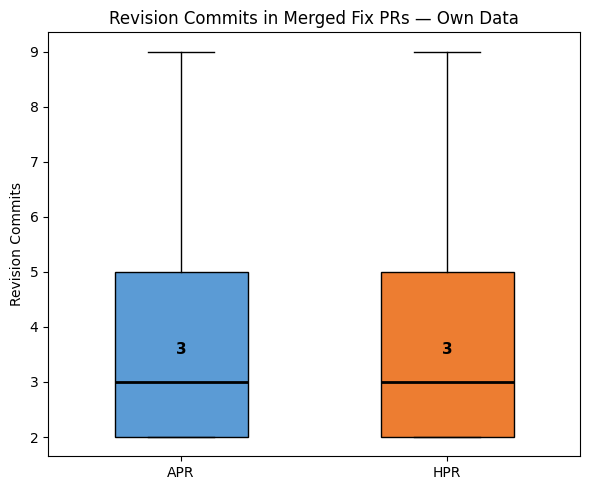


  -> Figure saved: results\own_data_report_figures\rq3_revision_commits.png


In [42]:
# Revision count box plot
fig, ax = plt.subplots(figsize=(6, 5))
data_rev, labels_rev = [], []
if len(apr_revised):
    data_rev.append(apr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("APR")
if len(hpr_revised):
    data_rev.append(hpr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("HPR")
if data_rev:
    bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, c in zip(bp["boxes"], ["#5b9bd5", "#ed7d31"]):
        patch.set_facecolor(c)
    for i, vals in enumerate(data_rev):
        med = np.median(vals)
        ax.text(i + 1, med + 0.5, f"{med:.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Revision Commits")
ax.set_title("Revision Commits in Merged Fix PRs — Own Data")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq3_revision_commits.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq3_revision_commits.png'}")

In [43]:
# Revision change size stats
def initial_and_revision_stats(revised_pr_ids, commits_df, details_df):
    pr_commits_ordered = commits_df[commits_df["pr_id"].isin(revised_pr_ids)].copy()
    first_commits = pr_commits_ordered.groupby("pr_id").first().reset_index()
    first_shas = set(first_commits["sha"])

    init_details = details_df[details_df["sha"].isin(first_shas)]
    init_stats = init_details.groupby("pr_id").agg(
        init_files=("filename", "nunique"),
        init_added=("additions", "sum"),
        init_deleted=("deletions", "sum"),
    ).reset_index()
    init_stats["init_total_changes"] = init_stats["init_added"] + init_stats["init_deleted"]

    rev_shas = set(pr_commits_ordered["sha"]) - first_shas
    rev_details = details_df[details_df["sha"].isin(rev_shas)]
    rev_stats = rev_details.groupby("pr_id").agg(
        rev_files_changed=("filename", "nunique"),
        rev_lines_added=("additions", "sum"),
        rev_lines_deleted=("deletions", "sum"),
    ).reset_index()
    rev_stats["rev_total_changes"] = rev_stats["rev_lines_added"] + rev_stats["rev_lines_deleted"]

    merged = rev_stats.merge(init_stats[["pr_id", "init_total_changes"]], on="pr_id", how="left")
    merged["pct_modification"] = (
        merged["rev_total_changes"] / merged["init_total_changes"].replace(0, np.nan) * 100
    )
    return merged

apr_rev_ids = set(apr_revised["pr_id"])
hpr_rev_ids = set(hpr_revised["pr_id"])

if apr_rev_ids or hpr_rev_ids:
    apr_rev_stats = initial_and_revision_stats(apr_rev_ids, commits, details) if apr_rev_ids else pd.DataFrame()
    hpr_rev_stats = initial_and_revision_stats(hpr_rev_ids, commits, details) if hpr_rev_ids else pd.DataFrame()

    out("\nRevision effort (median, revised PRs only):")
    out("  Metric (2) - Files changed in revisions:")
    a_med = apr_rev_stats["rev_files_changed"].median() if len(apr_rev_stats) else 0
    h_med = hpr_rev_stats["rev_files_changed"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_med:.0f}   HPR: {h_med:.0f}")

    out("  Metric (3) - Lines added/deleted in revisions:")
    for metric in ["rev_lines_added", "rev_lines_deleted"]:
        a_med = apr_rev_stats[metric].median() if len(apr_rev_stats) else 0
        h_med = hpr_rev_stats[metric].median() if len(hpr_rev_stats) else 0
        out(f"    {metric:<25s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

    out("  Metric (4) - % code modification vs initial submission:")
    a_pct = apr_rev_stats["pct_modification"].median() if len(apr_rev_stats) else 0
    h_pct = hpr_rev_stats["pct_modification"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_pct:.1f}%   HPR: {h_pct:.1f}%")


Revision effort (median, revised PRs only):
  Metric (2) - Files changed in revisions:
    APR: 2   HPR: 2
  Metric (3) - Lines added/deleted in revisions:
    rev_lines_added            APR:       26   HPR:       10
    rev_lines_deleted          APR:       14   HPR:        5
  Metric (4) - % code modification vs initial submission:
    APR: 120.5%   HPR: 85.7%


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\2712685159.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\2712685159.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\2712685159.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


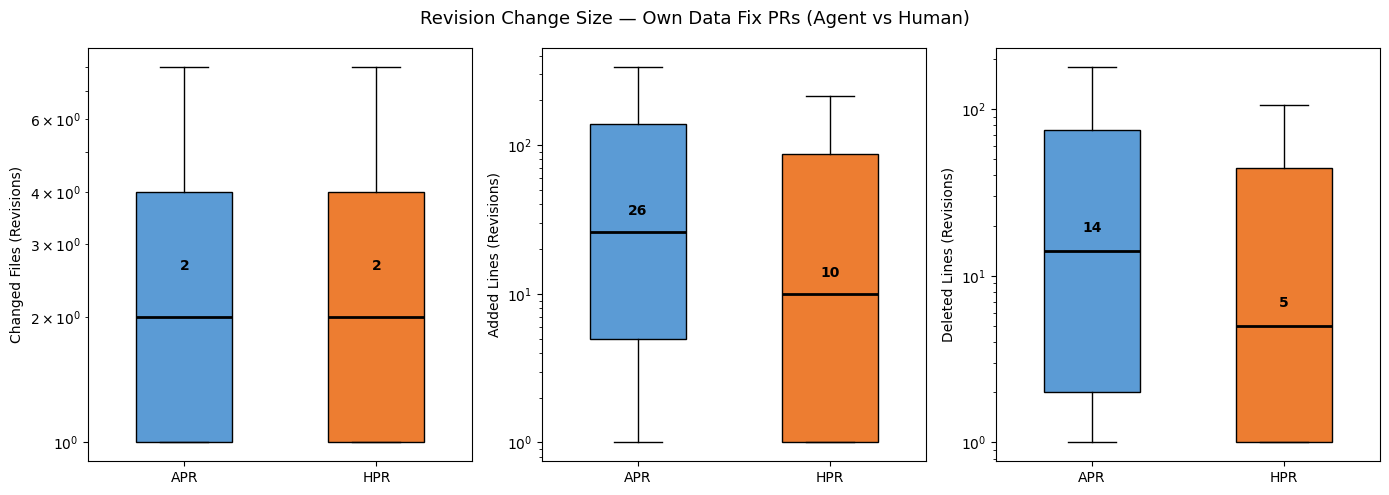

  -> Figure saved: results\own_data_report_figures\rq3_revision_change_size.png


In [44]:
# Revision change size box plots
if apr_rev_ids or hpr_rev_ids:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    rev_metrics = ["rev_files_changed", "rev_lines_added", "rev_lines_deleted"]
    rev_titles = ["Changed Files (Revisions)", "Added Lines (Revisions)", "Deleted Lines (Revisions)"]
    for ax, metric, title in zip(axes, rev_metrics, rev_titles):
        apr_vals = apr_rev_stats[metric].dropna().clip(lower=1).values if len(apr_rev_stats) else np.array([])
        hpr_vals = hpr_rev_stats[metric].dropna().clip(lower=1).values if len(hpr_rev_stats) else np.array([])
        data = [apr_vals, hpr_vals]
        bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                        widths=0.5, showfliers=False,
                        medianprops=dict(color="black", linewidth=2))
        bp["boxes"][0].set_facecolor("#5b9bd5")
        bp["boxes"][1].set_facecolor("#ed7d31")
        ax.set_yscale("log")
        ax.set_ylabel(title)
        for i, vals in enumerate(data):
            if len(vals):
                med = np.median(vals)
                ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")
    fig.suptitle("Revision Change Size — Own Data Fix PRs (Agent vs Human)", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq3_revision_change_size.png", dpi=150, bbox_inches="tight")
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq3_revision_change_size.png'}")

## Additional Statistics

In [45]:
section("Additional Statistics")

out("PR state breakdown:")
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    out(f"  {label}:")
    for state, cnt in df["state"].value_counts().items():
        out(f"    {state:12s} {cnt:>8,}")


  Additional Statistics
PR state breakdown:
  Agent:
    closed          2,620
  Human:
    closed          2,620


In [55]:
# Monthly trends
all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")
all_prs["is_agent"] = all_prs["source"] == "agent"
monthly = all_prs.groupby(["created_month", "is_agent"]).size().unstack(fill_value=0)

out("\nMonthly PR volume:")
out(f"{'Month':<12} {'Agent':>8} {'Human':>8} {'Total':>8}")
out("-" * 40)
for period in monthly.index:
    row = monthly.loc[period]
    agent_val = row.get(True, row.get("Agent", 0))
    human_val = row.get(False, row.get("Human", 0))
    total = agent_val + human_val
    out(f"{str(period):<12} {int(agent_val):>8,} {int(human_val):>8,} {int(total):>8,}")


Monthly PR volume:
Month           Agent    Human    Total
----------------------------------------
2024-12         2,924    5,703    8,627
2025-01         3,158    6,530    9,688
2025-02         3,840    6,830   10,670
2025-03         4,854    7,680   12,534
2025-04         5,041    7,495   12,536
2025-05         7,459    7,392   14,851
2025-06        12,729    7,585   20,314
2025-07        25,354    8,692   34,046
2025-08        10,802    7,469   18,271
2025-09         7,123    7,993   15,116
2025-10         6,396    8,459   14,855
2025-11         6,154    7,757   13,911
2025-12         5,816    7,771   13,587
2026-01         6,851    9,001   15,852
2026-02         7,510    9,654   17,164


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_2656\399809152.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")


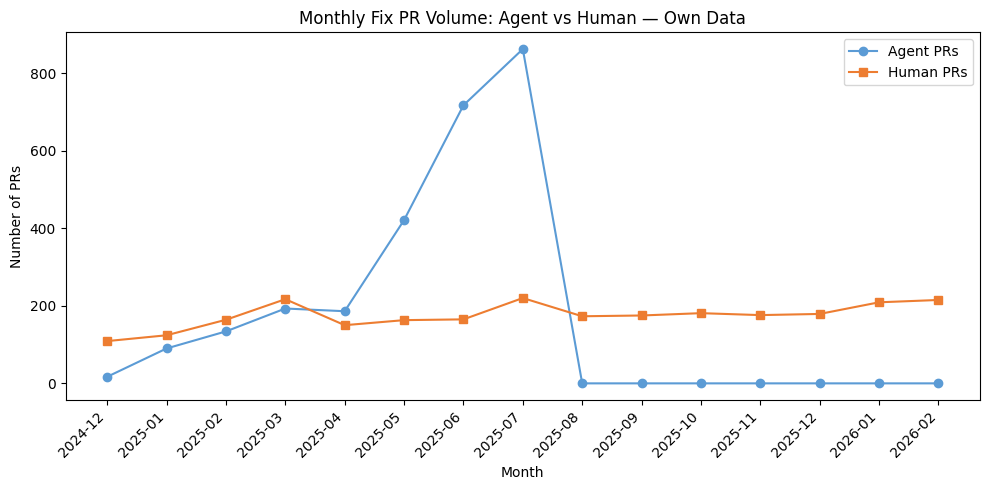


  -> Figure saved: results\own_data_report_figures\monthly_trend.png


In [47]:
# Monthly trend chart
fig, ax = plt.subplots(figsize=(10, 5))
months_str = [str(p) for p in monthly.index]
agent_vals = [monthly.loc[p].get(True, monthly.loc[p].get("Agent", 0)) for p in monthly.index]
human_vals = [monthly.loc[p].get(False, monthly.loc[p].get("Human", 0)) for p in monthly.index]
ax.plot(months_str, agent_vals, "o-", label="Agent PRs", color="#5b9bd5")
ax.plot(months_str, human_vals, "s-", label="Human PRs", color="#ed7d31")
ax.set_xlabel("Month")
ax.set_ylabel("Number of PRs")
ax.set_title("Monthly Fix PR Volume: Agent vs Human — Own Data")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_trend.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_trend.png'}")

In [48]:
# Top repositories
out("\nTop 10 repos by total PRs:")
top_repos = all_prs["repo_name"].value_counts().head(10)
for repo, cnt in top_repos.items():
    agent_cnt = len(all_prs[(all_prs["repo_name"] == repo) & (all_prs["is_agent"] == True)])
    out(f"  {repo:50s}  total: {cnt:>5,}  agent: {agent_cnt:>5,}")


Top 10 repos by total PRs:
  crewAIInc/crewAI                                    total:   234  agent:   230
  elastic/kibana                                      total:   131  agent:     2
  microsoft/vscode                                    total:   128  agent:    75
  PostHog/posthog                                     total:   126  agent:     1
  getsentry/sentry                                    total:   112  agent:    10
  calcom/cal.com                                      total:   108  agent:    54
  ydb-platform/ydb                                    total:    76  agent:     1
  MetaMask/metamask-mobile                            total:    69  agent:     3
  RooCodeInc/Roo-Code                                 total:    61  agent:     1
  liam-hq/liam                                        total:    61  agent:    56


## Save Report

In [49]:
REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nReport saved to {REPORT_PATH}")
print(f"Figures saved to {FIG_DIR}/")
print("Done!")


Report saved to results\own_data_report.txt
Figures saved to results\own_data_report_figures/
Done!
